# TDDE58 Lab
### Author: Sofia Knutas

In [145]:
# ---- Import required packets -----
import numpy as np
import matplotlib.pyplot as plt

# ---- Fixed parameters ----
SEED = 42           # set for reproducibility
N0 = 1e-9          # thermal noise power (mW)
alpha = 4           # path loss exponent
n_slots = int(1e5)  # number of simulated slots, should be large enough to reach a steady state

rng = np.random.default_rng(SEED)

#### Configure channel gains
The fading varaibles h1 and h2 are independent exponential random variables with mean one, redrawn each slot. Here, we are just testing it for our own understanding. 

mean h1: 1.0034967312171512
mean h2: 0.9946108718841656


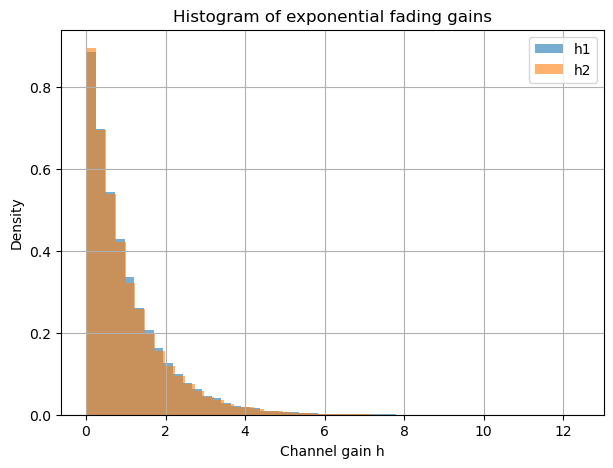

In [146]:
h1 = rng.exponential(1.0, n_slots)
h2 = rng.exponential(1.0, n_slots)

print("mean h1:", h1.mean())   # should be close to 1
print("mean h2:", h2.mean())   # should be close to 1

plt.figure(figsize=(7, 5))
plt.hist(h1, bins=50, alpha=0.6, label='h1', density=True)
plt.hist(h2, bins=50, alpha=0.6, label='h2', density=True)
plt.xlabel('Channel gain h')
plt.ylabel('Density')
plt.title('Histogram of exponential fading gains')
plt.legend()
plt.grid(True)
plt.show()

#### Set parameters for the simualtion


In [147]:
P_values = [1, 2, 4]       # mW
r_values = [200, 400]      # m
gamma_values = [0.2, 1, 3]


#### Simulate the different protocols as functions

In [148]:
def simulate_tdma(P, r, gamma, n_slots, rng):
    """TDMA: user 1 gets odd slots, user 2 gets even slots. There can be no interference."""
    h1 = rng.exponential(1.0, n_slots)
    h2 = rng.exponential(1.0, n_slots)

    snr1 = P * h1 * r**(-alpha) / N0
    snr2 = P * h2 * r**(-alpha) / N0

    user1_slots = np.arange(n_slots) % 2 == 0
    user2_slots = ~user1_slots

    success1 = np.sum(snr1[user1_slots] > gamma)
    success2 = np.sum(snr2[user2_slots] > gamma)

    throughput = (success1 + success2) / n_slots
    return throughput


def simulate_aloha(P, r, gamma, n_slots, rng):
    """Slotted ALOHA with q=1, so both users transmit every slot."""
    h1 = rng.exponential(1.0, n_slots)
    h2 = rng.exponential(1.0, n_slots)

    rx1 = P * h1 * r**(-alpha)
    rx2 = P * h2 * r**(-alpha)

    sinr1 = rx1 / (rx2 + N0)
    sinr2 = rx2 / (rx1 + N0)

    success1 = np.sum(sinr1 > gamma)
    success2 = np.sum(sinr2 > gamma)

    throughput = (success1 + success2) / n_slots
    return throughput

#### Create the plots
Outer loops goes over the gamma values, and here the three figures are created respectively. 
Then we have an inner loop running over the r, radius, from where we can actually then get the four curves. 
Lastly, we also run over the P values in the most inner loop. 

gamma=0.2, r=200 m
  TDMA:  ['7.2746e-01', '8.5163e-01', '9.2337e-01']
  ALOHA: ['1.2108e+00', '1.4198e+00', '1.5414e+00']
gamma=0.2, r=400 m
  TDMA:  ['5.7000e-03', '7.6830e-02', '2.7828e-01']
  ALOHA: ['9.8700e-03', '1.2824e-01', '4.6258e-01']


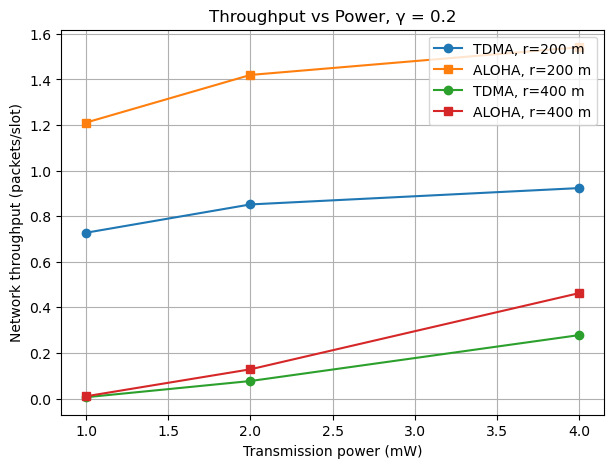

gamma=1, r=200 m
  TDMA:  ['2.0231e-01', '4.4812e-01', '6.6903e-01']
  ALOHA: ['2.0185e-01', '4.4895e-01', '6.7190e-01']
gamma=1, r=400 m
  TDMA:  ['0.0000e+00', '0.0000e+00', '1.6400e-03']
  ALOHA: ['0.0000e+00', '0.0000e+00', '1.4500e-03']


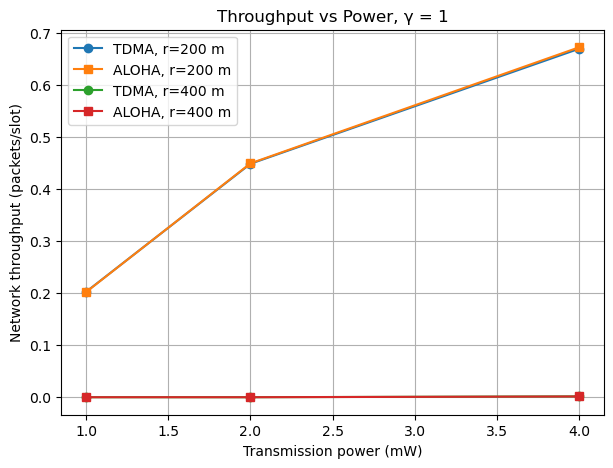

gamma=3, r=200 m
  TDMA:  ['8.2500e-03', '9.0330e-02', '3.0267e-01']
  ALOHA: ['4.3200e-03', '4.5350e-02', '1.5305e-01']
gamma=3, r=400 m
  TDMA:  ['0.0000e+00', '0.0000e+00', '0.0000e+00']
  ALOHA: ['0.0000e+00', '0.0000e+00', '0.0000e+00']


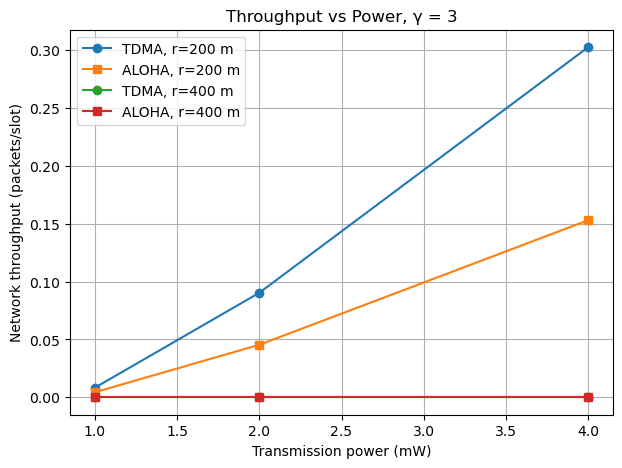

In [149]:
for gamma in gamma_values:
    plt.figure(figsize=(7, 5))

    for r in r_values:
        tdma_throughput = [simulate_tdma(P, r, gamma, n_slots, rng) for P in P_values]
        aloha_throughput = [simulate_aloha(P, r, gamma, n_slots, rng) for P in P_values]

        print(f"gamma={gamma}, r={r} m")
        print(f"  TDMA:  {[f'{v:.4e}' for v in tdma_throughput]}")
        print(f"  ALOHA: {[f'{v:.4e}' for v in aloha_throughput]}")

        plt.plot(P_values, tdma_throughput, marker='o', label=f'TDMA, r={r} m')
        plt.plot(P_values, aloha_throughput, marker='s', label=f'ALOHA, r={r} m')

    plt.xlabel('Transmission power (mW)')
    plt.ylabel('Network throughput (packets/slot)')
    plt.title(f'Throughput vs Power, γ = {gamma}')
    plt.legend()
    plt.grid(True)
    plt.show()

#### Discussion on the figures
1. Figure 1 (γ = 0.2): Aloha performs better in both 200m and 400m, even though the difference is bigger on the shorter distance between the two. When the r is 400m both have a hard time to have barely any throughput when the transmission power is low, which is logical since we know that longer distance -> less throughput.

2. Figure 2 (γ = 1): At r=200m, TDMA and ALOHA are nearly identical at every power level. At r=400m, both crash to near-zero, with only P=4mW producing any successes at all, and TDMA performing out ALOHA very slightly there, but not anything significant. However this is an intersting result since we here can come to the conclusion that the increaded gamma now makes ALOHA lose its earlier advantage. At γ=0.2, ALOHA had a clear lead over TDMA and just increasing γ=1, that lead is gone. Here we can conclude that ALOHA gets "two attempts per slot," but pays an interference penalty. This results therefore shows that the interference is more sensitive to γ increasing.
  

3. Figure 3 (γ = 3): At r=200m, TDMA clearly outperforms ALOHA now. However, at r=400m, every power level tested gives only zeros for both protocols. The signal is too weak to reach up to γ in all cases.
ALOHA's relative performance drop is big between γ=1 and γ=3, this is because tripling γ also triples the size of the interference penalty. This then means that the same interference is being weighed against an increasingly demanding standard and that's why ALOHA doesn't just lose a little more between γ=1 and γ=3, since the fixed 2×-attempts benefit stays flat while the interference penalty keeps scaling up as gamma does.

#### Key takeaways: 
- The interference is a fixed presence, but its impact grows with γ. At low γ, that interference term almost does not matter. So at low γ, interference is technically worse than a world with no interference at all, but not bad enough to erase ALOHA's advantage over TDMA since it always sends two packets instead of one. As γ rises, that same interference term costs more and more, until eventually it costs enough to cancel out the 2× benefit entirely, which is when TDMA starts winning instead.

- Since h has mean 1, the avarage SNR at a given P and r is:
$$\overline{SNR} = \frac{P \cdot r^{-4}}{N_0}$$
At r=400m: $r^{-4} = 400^{-4} \approx 3.91 \times 10^{-11}$
Even at the highest tested power (P=4mW) the avarage slot isn't close to succeeding; a packet only gets through when the random channel gain h happens to be very much larger than usual. And because h is exponential with mean 1, the probability of drawing a value that large is unlikely and rare.
  

#### Plots of performance vs distance in scenario with a fixed power

gamma=1, r=30.0 m
  TDMA:  ['9.9963e-01', '9.9747e-01', '9.9254e-01', '9.7981e-01', '9.5608e-01', '9.1816e-01', '8.6466e-01', '7.8845e-01', '6.9204e-01', '5.8128e-01', '4.5942e-01', '3.3852e-01', '2.3233e-01', '1.4584e-01', '8.2390e-02', '4.0440e-02', '1.7180e-02', '6.7000e-03', '2.1600e-03', '6.5000e-04']
  ALOHA: ['9.9963e-01', '9.9742e-01', '9.9210e-01', '9.8039e-01', '9.5684e-01', '9.1720e-01', '8.6230e-01', '7.8879e-01', '6.9322e-01', '5.8128e-01', '4.6190e-01', '3.4261e-01', '2.3288e-01', '1.4618e-01', '8.2680e-02', '3.9870e-02', '1.8540e-02', '6.6200e-03', '1.9600e-03', '6.3000e-04']


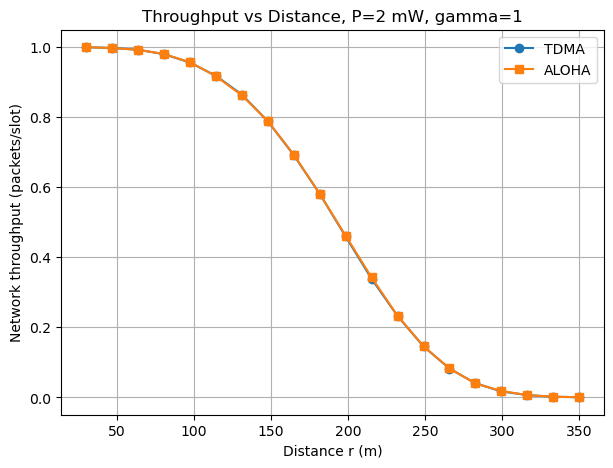

In [150]:
P_fixed = 2       # mW
gamma_fixed = 1
r_range = np.linspace(30, 350, 20)

tdma_vs_r = [simulate_tdma(P_fixed, r, gamma_fixed, n_slots, rng) for r in r_range]
aloha_vs_r = [simulate_aloha(P_fixed, r, gamma_fixed, n_slots, rng) for r in r_range]

print(f"gamma={gamma_fixed}, r={r_range[0]} m")
print(f"  TDMA:  {[f'{v:.4e}' for v in tdma_vs_r]}")
print(f"  ALOHA: {[f'{v:.4e}' for v in aloha_vs_r]}")

plt.figure(figsize=(7, 5))
plt.plot(r_range, tdma_vs_r, marker='o', label='TDMA')
plt.plot(r_range, aloha_vs_r, marker='s', label='ALOHA')
plt.xlabel('Distance r (m)')
plt.ylabel('Network throughput (packets/slot)')
plt.title(f'Throughput vs Distance, P={P_fixed} mW, gamma={gamma_fixed}')
plt.legend()
plt.grid(True)
plt.savefig('throughput_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()

- I started with a range from 50m to 600m with measure steps of 20m. Using this values it was clear that between approximately 100-300m there was a linear tendency of around -0.5 packets/slot for every 100m. After about 300m the throutghput was converging -> 0. Both TDMA and ALOHA performed similar. 
- A second and last try was made with a range from 30m to 350m. Here we could observe the decline in throughput closer and can conclude that the significant packet loss starts between 50-100m and after that declines fast until about 250m where it level offs a bit and slowly starts converging towards 0.

Motivation for fixed varaiable values: In this experiment γ = 1, and P=2 was used. This values were selected since we earlier concluded that γ = 1 is where TDMA and ALOHA start performing similarly since the ALOHA protocols advantage of being able to send two packets every slot is canceled by its interference penalty, but not yet as hard so that TDMA starts outperforming it. Furthemore, P=2 was choosen since we can tell from the earlier experiments that this power is sufficent to keep the throughput ≠ 0 in all cases where P=4 also had a throughput ≠ 0. We could of course use P = 4 instead, but since 2 already shows it holds up for an analytical experiment on the same level, there is not really a big difference in the way they would perform conceptually. 

#### Relaxing q
In this experiment we relax q in the aloha protocol so that is varying instead of only staying at the expected value 1 at all times. Therefore we have to introduce a probability of q1 and q2 transmitting independently. 

In [151]:
def simulate_aloha_q(P, r, gamma, q1, q2, n_slots, rng):
    h1 = rng.exponential(1.0, n_slots)
    h2 = rng.exponential(1.0, n_slots)

    tx1 = rng.random(n_slots) < q1 # user 1 transmits with probability q1
    tx2 = rng.random(n_slots) < q2 # user 2 transmits with probability q2

    rx1 = P * h1 * r**(-alpha)
    rx2 = P * h2 * r**(-alpha)

    sinr1 = rx1 / (N0 + rx2 * tx2)
    sinr2 = rx2 / (N0 + rx1 * tx1)

    success1 = np.sum(tx1 & (sinr1 > gamma))
    success2 = np.sum(tx2 & (sinr2 > gamma))

    throughput1 = success1 / n_slots
    throughput2 = success2 / n_slots
    total = throughput1 + throughput2

    return throughput1, throughput2, total


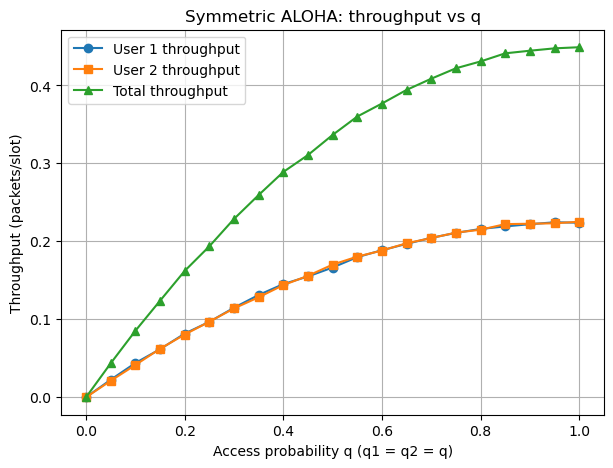

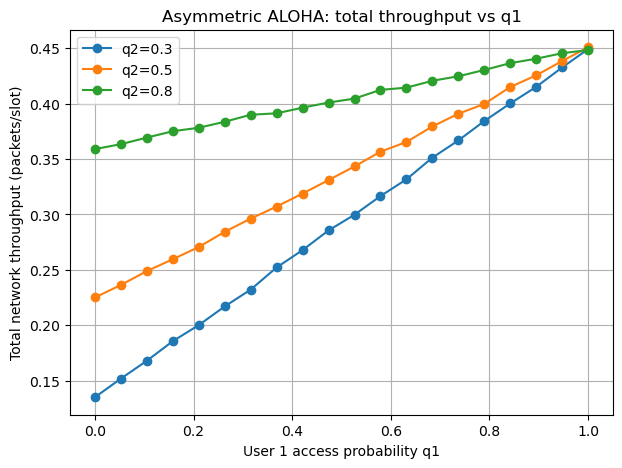

In [152]:
r_fixed = 200  
P_fixed = 2        
gamma_fixed = 1       

# ---------- Part A: symmetric sweep, q1 = q2 = q ----------
q_values = np.linspace(0, 1, 21)

throughput1_sym = []
throughput2_sym = []
total_sym = []

for q in q_values:
    t1, t2, total = simulate_aloha_q(P_fixed, r_fixed, gamma_fixed, q, q, n_slots, rng)
    throughput1_sym.append(t1)
    throughput2_sym.append(t2)
    total_sym.append(total)

plt.figure(figsize=(7, 5))
plt.plot(q_values, throughput1_sym, marker='o', label='User 1 throughput')
plt.plot(q_values, throughput2_sym, marker='s', label='User 2 throughput')
plt.plot(q_values, total_sym, marker='^', label='Total throughput')
plt.xlabel('Access probability q (q1 = q2 = q)')
plt.ylabel('Throughput (packets/slot)')
plt.title(f'Symmetric ALOHA: throughput vs q')
plt.legend()
plt.grid(True)
plt.show()


# ---------- Part B: asymmetric, sweep q1 while q2 fixed at a few values ----------
q1_values = np.linspace(0, 1, 20)
q2_fixed_values = [0.3, 0.5, 0.8]   # a few different "how greedy is user 2" scenarios

plt.figure(figsize=(7, 5))

for q2 in q2_fixed_values:
    total_asym = []
    for q1 in q1_values:
        t1, t2, total = simulate_aloha_q(P_fixed, r_fixed, gamma_fixed, q1, q2, n_slots, rng)
        total_asym.append(total)
    plt.plot(q1_values, total_asym, marker='o', label=f'q2={q2}')

plt.xlabel('User 1 access probability q1')
plt.ylabel('Total network throughput (packets/slot)')
plt.title('Asymmetric ALOHA: total throughput vs q1')
plt.legend()
plt.grid(True)
plt.show()

In the symmetric case we can conclude that the users have aboout the same trhoughput, which is valid since in this case they have the same q. The throughput starts converging towards ≈0.45 when both ot the q->1. Therefore its fair to say that in this case with the scenario of the fixed constants its to advantage to be able to transmitt twice the packets in one slot rather than "taking random turns". 


In the assymmetric version where q2 where tested at 0.3, 0.5 and 0.8 simulating a moderate to greedy user and q1 was sweeped across 20 points between 0-1 we can see that the througput enlarges as q1 does, pretty much linearly. 

